<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/recitations/14_ImageProcessingRecitation_Repetition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.signal import convolve
from scipy.ndimage import median_filter
import random
random.seed(3)

In [2]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(fname:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        fname: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, fname)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [3]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

<div dir="rtl">

# 14 תרגול חזרה
<dir>

<div dir="rtl">

## 14.1 היסטוגרמה
* מה זה היסטוגרמה?

היסטוגרמה היא ייצוג סטטיסטי של התפלגות רמות האפור (או העוצמות) בתמונה. בעיבוד תמונה משתמשים בה כדי לנתח ולשפר את הקונטרסט של התמונה, לזהות אזורים כהים ובהירים, ולבצע פעולות כמו מתיחת קונטרסט והשוואת היסטוגרמות (Histogram Equalization).

* השוואת היסטוגרמה:

השוואת היסטוגרמה (Histogram Equalization) מבוצעת על־ידי חישוב ההיסטוגרמה של התמונה, נרמול שלה להסתברות, חישוב פונקציית ההתפלגות המצטברת (CDF), ושימוש בה כמיפוי לא לינארי (כלומר הקשר בין רמת האפור המקורית לרמת האפור החדשה אינו קו ישר) שמחליף כל רמת אפור בערך חדש כך שההתפלגות תהיה קרובה לאחידה.
<dir>

In [4]:
def histograms(img:np.array) -> (np.array, np.array):
    hist = np.zeros(256, dtype='int16')
    nrows, ncols = img.shape
    for r in range(nrows):
        for c in range(ncols):
            hist[img[r, c]] += 1

    acc_hist = np.zeros(256, dtype='int32')
    acc_hist[0] = hist[0]
    for i in range(1,256):
        acc_hist[i] = acc_hist[i-1] + hist[i]
    return hist, acc_hist / img.size

In [5]:
img = read_file(fname='house.tiff')

In [6]:
def plot_img_hist(img:np.array):
    hist, acc_hist = histograms(img)

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    axes[0].imshow(img,  cmap='gray', vmin=0, vmax=255)          #img

    axes[1].set_xlim([0, 256])                                   #histogram
    axes[1].set_ylim([0, hist[1:-1].max()])
    axes[1].bar(np.arange(len(hist)),height=hist);
    axes[2].set_xlim([0, 256])                                   #accumulated histogram
    axes[2].bar(np.arange(len(acc_hist)),height=acc_hist);

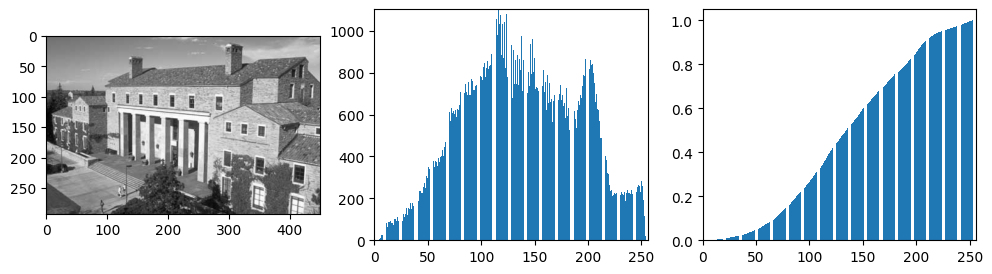

In [7]:
plot_img_hist(img)

<div dir="rtl">

### 14.1.1

פעולות על היסטוגרמה:

<dir>

<div dir="rtl">

הזזת היסטוגרמה - הגדלה או הקטנה של בהירות התמונה:

<dir>

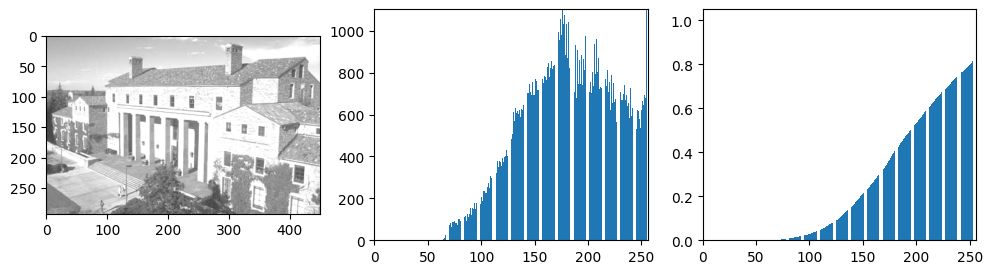

In [8]:
bright_img = np.clip(img + 60, a_min=0, a_max=255) #np.clip for overflow / underflow
plot_img_hist(bright_img)

<div dir="rtl">

כיווץ:


<dir>

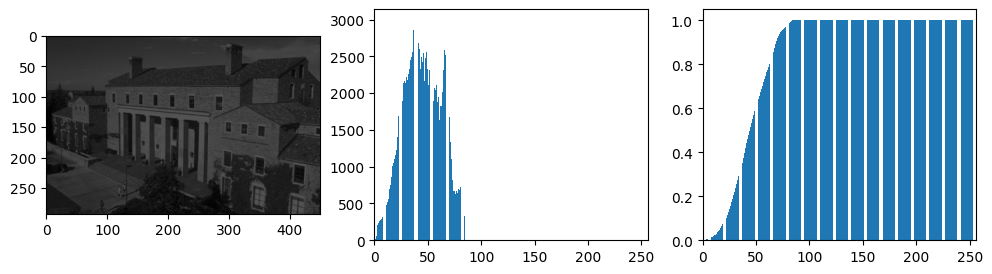

In [9]:
img1 = (img / 3).astype(np.int16) #division by 3
bright_img = np.clip(img1, a_min=0, a_max=255)
plot_img_hist(img1)

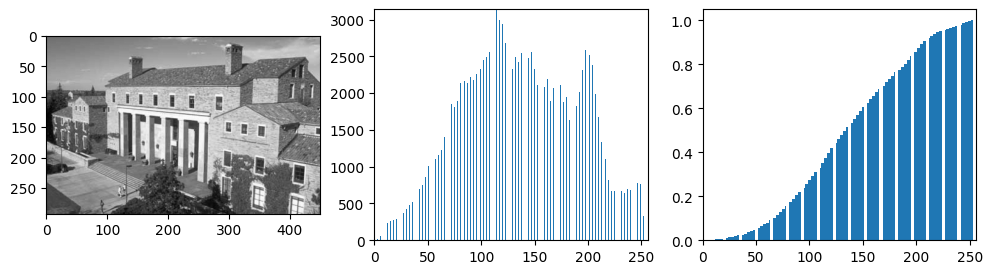

In [10]:
img2 = (img1 * 3).astype(np.int16)
img2 = np.clip(img2, a_min=0, a_max=255)
plot_img_hist(img2)

<div dir="rtl">

## 14.2 קונבולוציה רעש ומסננים
<dir>

<div dir="rtl">

## 14.2.1 מה זה קונבולוציה?

קונבולוציה היא פעולה מתמטית (אופרטור לינארי) שבה משלבים תמונה עם קרנל (מסנן לפי הפעולה שרוצים לבצע) כך שכל פיקסל חדש מתקבל כסכום משוקלל של שכניו, ובעיבוד תמונה משתמשים בה כדי לבצע סינון, טשטוש, חידוד וזיהוי מאפיינים מקומיים בתמונה.

<dir>

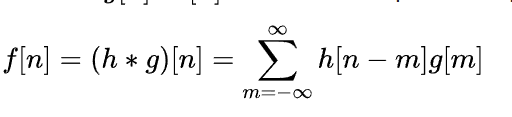

<div dir="rtl">

דגשים חשובים לקונבולציה:

* ריפוד (Padding): כדי לשמור על גודל התמונה לאחר הקונבולוציה נהוג לרפד את התמונה באפסים (Zero Padding) או בשיטות אחרות כמו שכפול קצוות (Replication) או רפלקציה.

* גודל הקרנל: קרנל גדול משפיע על אזור רחב יותר ומוביל לסינון חזק יותר אך עלול לטשטש פרטים.
* היפוך הקרנל: בקונבולוציה מתמטית הקרנל מתהפך ב־180° לפני החישוב (בניגוד לקורלציה).
* נרמול הקרנל: במסנני החלקה חשוב שסכום מקדמי הקרנל יהיה 1 כדי לשמור על רמת בהירות כללית.
* השפעת הקצוות: תוצאות הקונבולוציה בקצוות התמונה תלויות בשיטת הריפוד ועלולות ליצור ארטיפקטים.

<dir>

<div dir="rtl">

## 14.2.2 רעש ומסננים:
לכל רעש נתאים את המסנן שלו וע"י אופרטור הקונבולצויה נבצע את הסינון שלו.

<dir>

<div dir="rtl">

### סוגי רעשים:
<dir>

<div dir="rtl">

### 14.2.2.1 רעש גאוסיאני:
<dir>

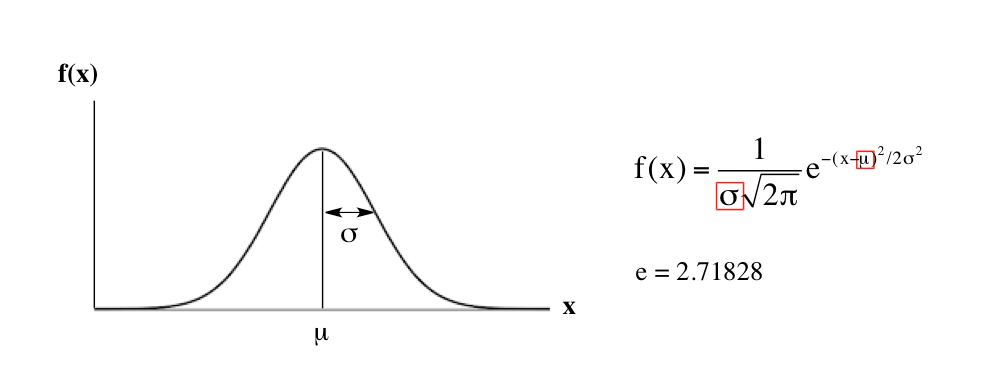

<div dir="rtl">

**שאלה:** איזה מסנן נשתמש?

**תשובה:** מסנן ממוצע או בגרסה יותר טובה שלו מסנן גאוסי.
<dir>

<div dir="rtl">

הוספת רעש גאוסי:
<dir>

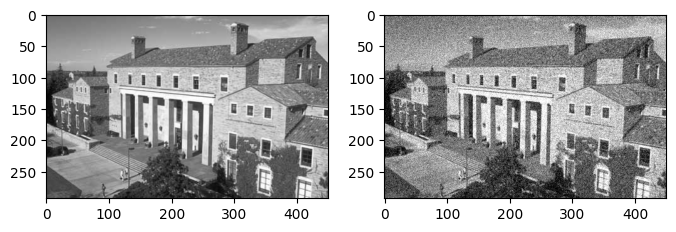

In [11]:
img = read_file(fname='house.tiff') / 255

img1 = img.copy()
nrows, ncols = img1.shape
for r in range(nrows):
    for c in range(ncols):
        img1[r,c] += np.random.normal(0.0, 0.1)
img1 = np.clip(img1, a_min=0.0, a_max=1.0)
plot_images(img, img1)

<div dir="rtl">

מסנן ממוצע בעזרת קונבולוציה:

**שאלה:** איך נראת המטריצה של המסנן?
<dir>

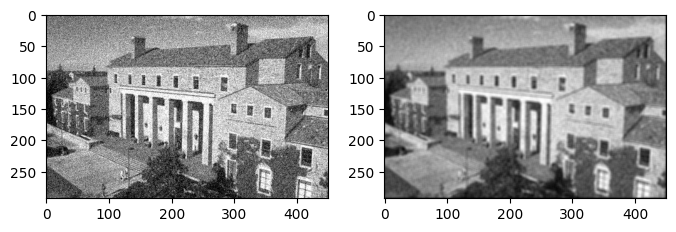

In [14]:
FILTER_SIZE = 5
filter=np.ones(shape=(FILTER_SIZE, FILTER_SIZE)) / (FILTER_SIZE**2)
img2 = convolve(in1=img1, in2=filter, mode='same')

plot_images(img1, img2)

<div dir="rtl">

מסנן גאוסי בעזרת קונבולוציה:

**שאלה:** איך נראת המטריצה של המסנן?
<dir>

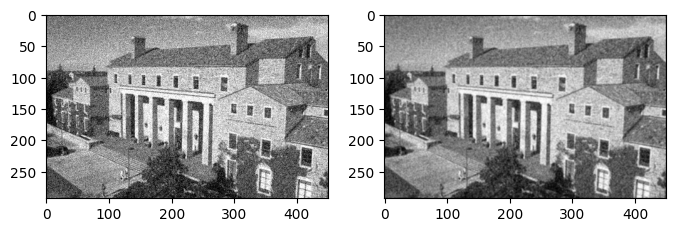

In [16]:
filter = np.array([[1,2,1],
                   [2,4,2],
                   [1,2,1]])
filter = filter / filter.sum()
img3 = convolve(in1=img1, in2=filter, mode='same')

plot_images(img1, img3)

<div dir="rtl">

### 14.2.2.2 רעש מלח פלפל:

<dir>

In [21]:
def sp_noise(img:np.array, d:float) -> np.array:
    '''
    add 'salt & pepper' noise with density d to an image, imnoise first assigns
    each pixel a random probability value from a standard uniform distribution
    on the open interval (0, 1).
    For pixels with probability value in the range (0, d/2), the pixel value is
      set to 0. The number of pixels that are set to 0 is
      approximately d*numel(I)/2.
    For pixels with probability value in the range [d/2, d), the pixel value is
      set to the maximum value of the image data type. The number of pixels that
      are set to the maximum value is approximately d*numel(I)/2.
    For pixels with probability value in the range [d, 1), the pixel value is
      unchanged.
    Args:
        img: image in float format (range: 0..1)
    Returns:
        img1: in float format (range: 0..1) - s&p noised image
    '''
    img1 = img.copy()
    nrows, ncols = img.shape
    for i in range(nrows):
        for j in range(ncols):
            rdn = random.random()
            if rdn <= d/2:
                img1[i][j] = 0.0
            elif d/2 < rdn < d:
                img1[i][j] = 1.0
            else:
                img1[i][j] = img[i][j]
    return img1

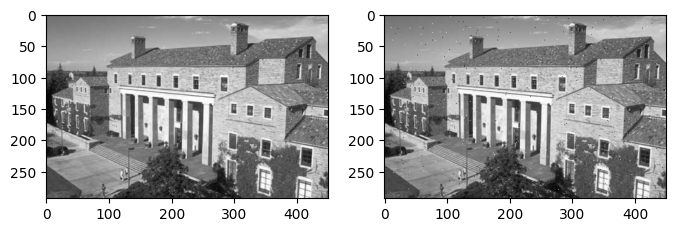

In [22]:
img = read_file(fname='house.tiff') / 255
img1 = sp_noise(img, 0.003)

plot_images(img, img1)

<div dir="rtl">

**שאלה:** איזה מסנן נשתמש?

**תשובה:** מסנן חציון Median Filter
<dir>

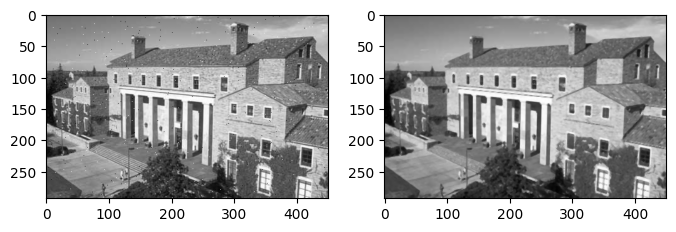

In [23]:
img2 = img1.copy()
img2 = median_filter(img, size=3)
plot_images(img1, img2)

<div dir="rtl">

### 14.2.2.3 רעש כיווני:

ע"י שימוש בקונובולוציה עם מסכה מתאימה,ניתן ליצור רעש בצורה כיוונית (אופקי/אנכי/צלב וכו'..)
<dir>

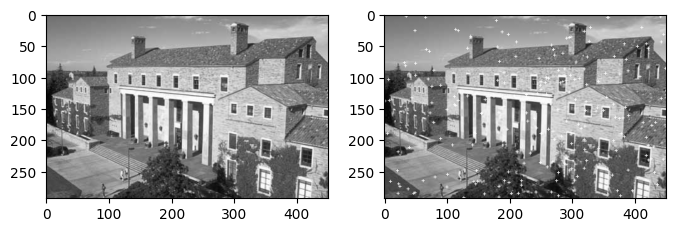

In [24]:
mask = np.zeros(shape=img.shape)
mask = sp_noise(mask, 0.003)
kernel = np.array([[0,0,1,0,0],
                   [0,0,1,0,0],
                   [1,1,1,1,1],
                   [0,0,1,0,0],
                   [0,0,1,0,0]])
mask = convolve(in1=mask, in2=kernel, mode='same')
mask = np.clip(mask, a_min=0.0, a_max=1.0)
img6 = np.maximum(img, mask)
plot_images(img,img6)

<div dir="rtl">

**שאלה:** איזה מסנן נשתמש?

**תשובה:** מסנן חציון כיווני
<dir>

<div dir="rtl">

### 14.2.3 מסכה תקינה:

* כל הערכים לא שליליים
* סכום המשקלים חיובי ומנורמל
* המסכה מבצעת החלקה אמיתית
* סימטריה לאורך הכיוון - שמירה על מסכה גיאומטרית סימטרית
* בלי קפיצות חדות


<dir>

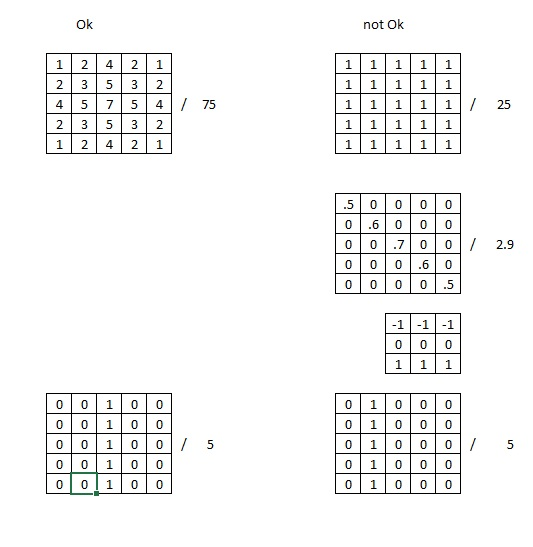

<div dir="rtl">

## 14.3 תמונות בינאריות:

<dir>

<div dir="rtl">

### 14.3.1 תמונה בינארית:


תמונה בינארית היא תמונה שבה כל פיקסל מקבל אחד משני ערכים בלבד היא נוצרת ע"י קביעת סף של רמת אפור שהופכת ל1 לוגי או 0 לוגי.
<dir>

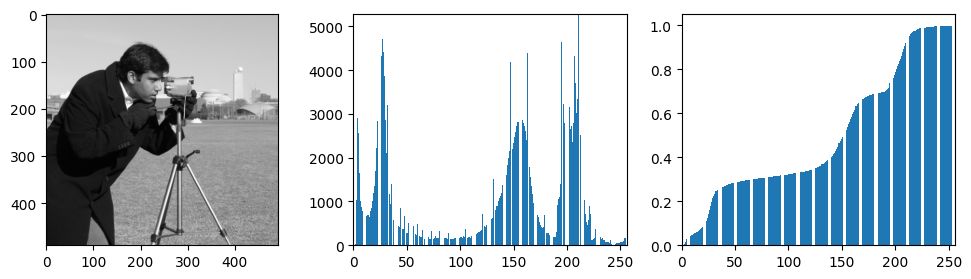

In [25]:
img = read_file('camera1.tif')[:,:,0]
plot_img_hist(img)

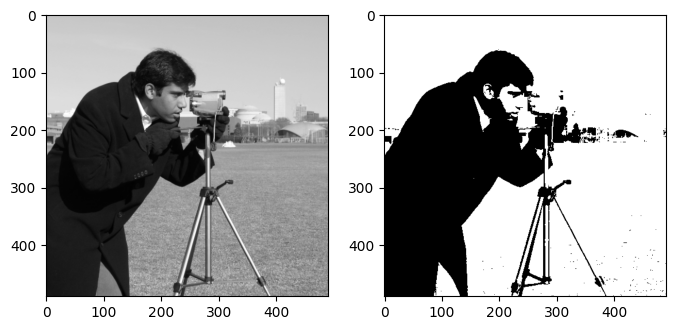

In [26]:
img_array = (img > 110)
img_1 = (img_array).astype('int16')
plot_images(img, img_1)

<div dir="rtl">

### 14.3.2 מרכיבים קשירים:

מרכיבים קשירים הם קבוצות של פיקסלים בעלי אותו ערך המחוברים זה לזה לפי הגדרת קשריות, ומטרתם לאפשר זיהוי, ספירה וניתוח של אובייקטים נפרדים בתמונה לאחר בינאריזציה.
<dir>

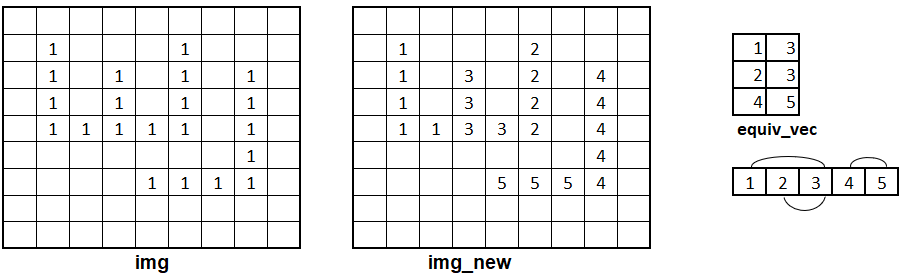

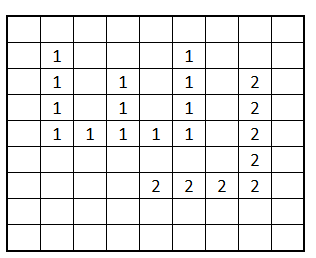

<div dir="rtl">

האלגוריתם המלא ליצירת מרכיבים קשירים נמצא בתרגול 7 ובמטלה 3.
<dir>

<div dir="rtl">

### 14.3.3 מציאת שלד:

מציאת שלד של תמונה היא תהליך שמצמצם אובייקטים לציר המרכזי שלהם תוך שמירה על הטופולוגיה ולא על העובי של האובייקט, ושחזור משלד מאפשר לשחזר קירוב של הצורה המקורית באמצעות הרחבה הדרגתית של השלד.
<dir>

<div dir="rtl">

ע"י אלגוריתם דילול איטרטיבי (Morphological Thinning):

האלגוריתם פועל ע״י הסרה הדרגתית של פיקסלים משולי האובייקט בתמונה בינארית, כל עוד ההסרה לא שוברת קשריות ולא משנה את הטופולוגיה, עד שנותר ציר מרכזי בעובי פיקסל אחד שהוא השלד.
<dir>

In [27]:
from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert

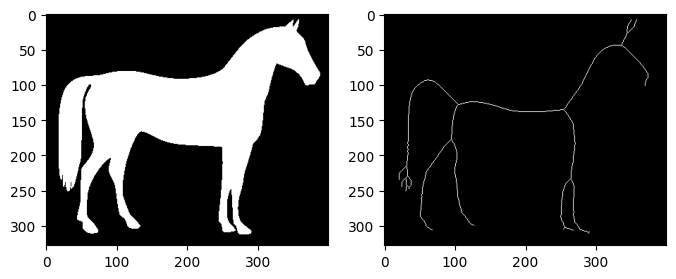

In [28]:
from skimage.draw import disk
img_1 = invert(data.horse())
skeleton, dist = medial_axis(img_1, return_distance=True)
masked = dist.copy()
plot_images(img_1, skeleton)

<div dir="rtl">

האלגוריתם המלא נמצא בתרגול 8 ובמטלה 3.
<dir>

<div dir="rtl">

### 14.3.4 אלגוריתם Canny:
<dir>

<div dir="rtl">

אלגוריתם Canny לזיהוי קצוות מזהה קצוות בצורה אופטימלית ע"י החלקת התמונה להפחתת רעש, חישוב גרדיאנט, Non-Maximum Suppression, וסף כפול עם hysteresis לשמירה על קצוות רציפים ואמינים.

במהלך Canny מחושבות ונשמרות:

* מטריצת עוצמת הגרדיאנט

* מטריצת כיוון הגרדיאנט
<dir>

In [29]:
img = read_file('balls4.tiff').astype('uint8')
import cv2

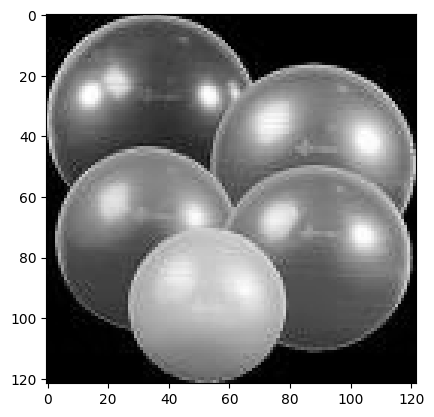

In [31]:
plt.imshow(img, cmap='gray');

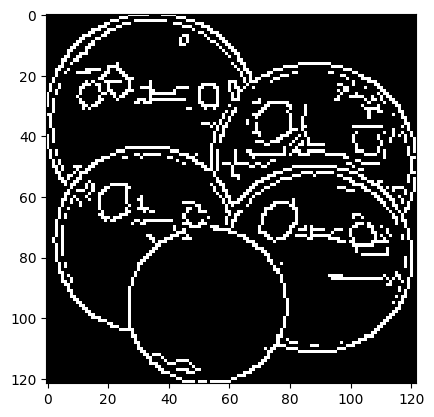

In [30]:
edges =cv2.Canny(image=img, threshold1=40, threshold2=140)
plt.imshow(edges, cmap='gray');

<div dir="rtl">

האלגוריתם המלא נמצא בתרגול 9 ובמטלה 4.
<dir>

<div dir="rtl">

### 14.3.5 אלגוריתם Hough Transform:
<dir>

<div dir="rtl">

אלגוריתם לזיהוי צורות גיאומטריות (כמו קווים או מעגלים) בתמונה על ידי מיפוי
נקודות קצה ממרחב התמונה למרחב פרמטרים ויצירת מטריצת הצטברות הצבעות של הפיקים במרחב הפרמטרים שמדגישה צורות.

דגש חשוב:

* כדי ליצור אלגוריתם יעיל ולצמצם את החישוב נשתמש במטריצת כיוון הגרדיאנט מאלגוריתם Canny כדי לבדוק רק את המרכזים שבכיוון הגרדיאנט.
<dir>



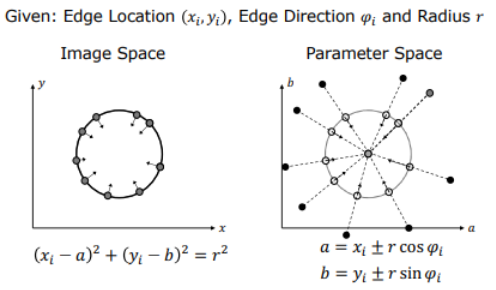

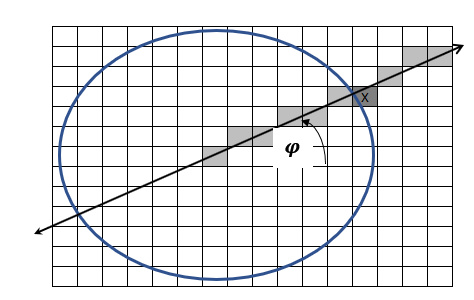

In [32]:
img = read_file('balls4.tiff').astype('uint8')

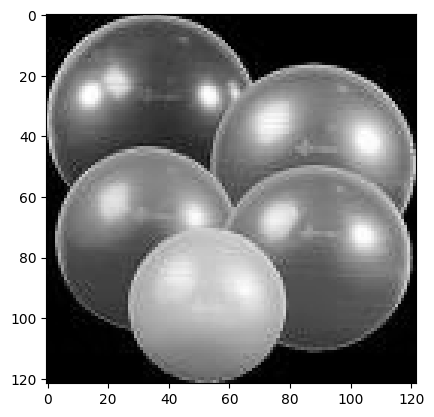

In [33]:
plt.imshow(img, cmap='gray');

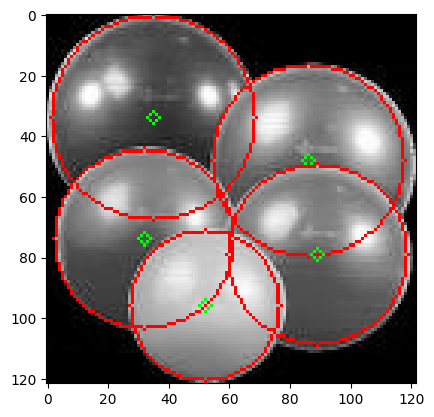

In [34]:
imgc = np.dstack((img, img, img))
import cv2
circles = cv2.HoughCircles(image=img,method=cv2.HOUGH_GRADIENT,dp=1,minDist=20,
                            param1=100,param2=41,minRadius=4,maxRadius=200).astype('uint16')
for i in circles[0,:]:
    cv2.circle(img=imgc,center=(i[0],i[1]),radius=i[2],color=(255,0,0),thickness=1)   # draw the outer circle
    cv2.circle(img=imgc,center=(i[0],i[1]),radius=2,color=(0,255,0),thickness=1)  # draw the center of the circle
plt.imshow(imgc, cmap='gray');

<div dir="rtl">

האלגוריתם המלא נמצא בתרגול 10 ובמטלה 4.
<dir>

<div dir="rtl">

## 14.4 FFT

אלגוריתם יעיל לחישוב התמרת פורייה הדיסקרטית של תמונה, ובהקשר של עיבוד תמונה הוא מאפשר מעבר מהמרחב המרחבי למישור התדר לצורך ניתוח תדירויות, סינון יעיל (כגון LPF ו-HPF) ושיפור מאפיינים גלובליים של התמונה.

ההנחה הבסיסית של התמרת פורייה היא שכל אות (גם אם אינו מחזורי) ניתן לייצג כסכום רציף או בדיד של גלים הרמוניים מחזוריים (סינוסים וקוסינוסים) בתדרים שונים, כאשר כל תדר מיוצג על־ידי מקדם המתאר את עוצמתו והפאזה שלו.

<dir>

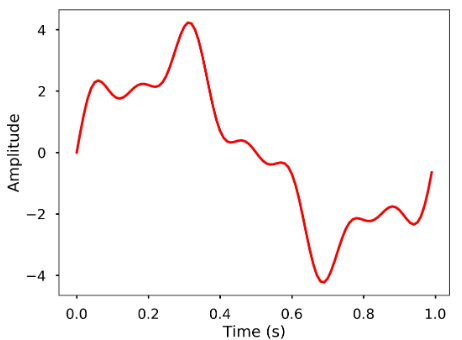

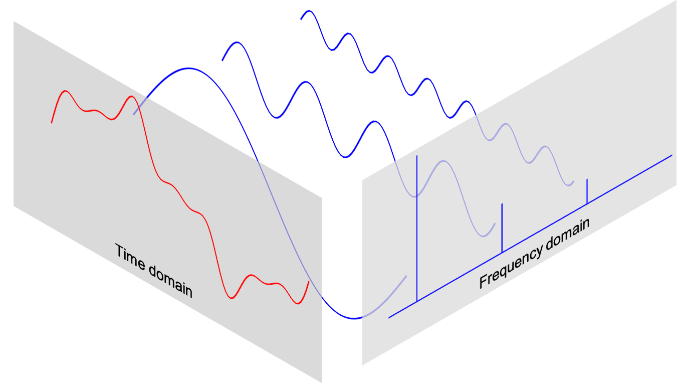

<div dir="rtl">


FFT (Fast Fourier Transform) הוא אלגוריתם יעיל לחישוב התמרת פורייה הדיסקרטית של תמונה, ובהקשר של עיבוד תמונה הוא מאפשר מעבר מהמרחב המרחבי למישור התדר לצורך ניתוח תדירויות, סינון יעיל (כגון LPF ו-HPF) ושיפור מאפיינים גלובליים של התמונה.
<dir>

<div dir="rtl">

### 14.4.1 דגימה:

דגימה היא תהליך של ייצוג אות רציף באמצעות ערכים בדידים במרווחים קבועים, המאפשר עיבוד וחישוב דיגיטליים. ע"י דגימה ניתן לעבור מאות רציף לייצוג בדיד, ומהתמרת פורייה רציפה לייצוג תדרי בדיד, שעל בסיסו מוגדרת התמרת פורייה הדיסקרטית.
<dir>

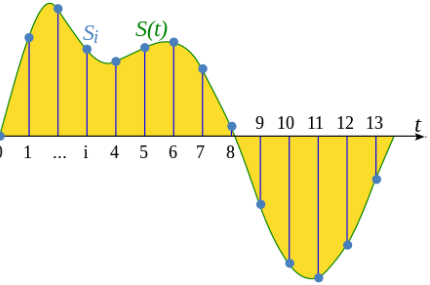

<div dir="rtl">

### 14.4.2 תדר נייקוייסט:

תדר נייקוויסט הוא חצי מתדר הדגימה והוא התדר הגבוה ביותר שניתן לייצג ללא איבוד מידע.
<dir>

<div dir="rtl">

### 14.4.3 קיפול תדרים (Aliasing):

קיפול תדרים מתרחש כאשר הדגימה אינה מספקת, ותדרים גבוהים מתחזים לתדרים נמוכים וגורמים לעיוות בלתי־הפיך באות.
<dir>

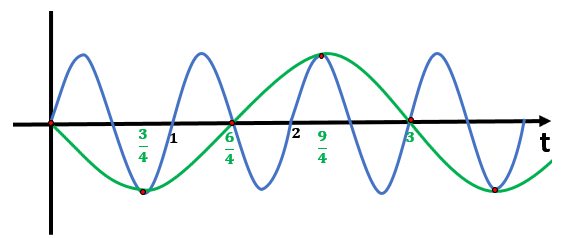

<div dir="rtl">

### 14.4.4 משפט הקונבולוציה:

משפט הקונבולוציה קובע שקונבולוציה במרחב שקולה לכפל במישור התדר, ומהווה בסיס לסינון יעיל באמצעות FFT.

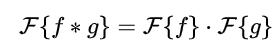

כאשר $F[f]$ מציין את התמרת הפוריה של $f$.
<dir>

<div dir="rtl">

### 14.4.5 מסנן LPF:

מסנן מעביר תדרים נמוכים (low-pass filter) – מעביר רק אותות עד תדר מסוים. כל תדר גבוה יותר מסונן. משמש לסינון רעשים מאותות שמע.

* מסנן גאוסי הוא בעצם מסנן LPF.
<dir>

<div dir="rtl">

### 14.4.6 מסנן HPF:

מסנן מעביר תדרים גבוהים (high-pass filter) – תפקידו להעביר אותות שהתדר שלהם גבוה מתדר מסוים. כל תדר נמוך יותר מסונן.

* מסנן גאוס - 1 הוא בעצם מסנן HPF.
<dir>

<div dir="rtl">

### 14.4.7 מסנן BSF:

מסנן חוסם פס (band-stop filter) - תפקידו לחסום תחום-תדר מסוים ואת השאר להעביר (נקרא גם Notch). בדרך כלל משמש במקומות שבהם תדר מסוים מפריע לקליטה.
<dir>

<div dir="rtl">

### 14.4.8 מסנן BPF:

מסנן מעביר פס (band-pass filter) – תפקידו להעביר רק רוחב סרט מסוים, ומסנן את כל שאר התחומים. בדרך כלל ממומש במקלטים או מגברים.
<dir>

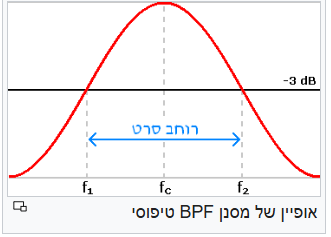

<div dir="rtl">

### 14.4.9 סיבוכיות ריצה:

* סיבוכיות הריצה של DFT על תמונה מגודל $N \times N$ תיהיה $O(N^4)$.

* סיבוכיות הריצה של חישוב FFT על תמונה מגודל $N \times N$ תיהיה $O(N^2logN)$.

* בעוד שסיבוכיות הריצה של קונבולוציה במישור המיקום תיהיה $O(N^2\times K^2)$.
<dir>